In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier, VotingRegressor
from sklearn.svm import SVC, SVR

from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error, r2_score

In [15]:
df = pd.read_csv("student_exam_performance_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (10000, 23)
  student_id  gender  age parental_education family_income internet_access  \
0     S00001    Male   17        High School        Medium             Yes   
1     S00002  Female   18        High School           Low             Yes   
2     S00003    Male   17        High School        Medium              No   
3     S00004    Male   18           Bachelor        Medium             Yes   
4     S00005    Male   18           Bachelor        Medium             Yes   

  study_environment  study_hours_per_day  attendance_rate  sleep_hours  ...  \
0             Quiet                 2.98             96.5         6.05  ...   
1             Quiet                 4.45             95.7         6.96  ...   
2             Quiet                 3.75             76.0         7.02  ...   
3             Quiet                 2.03             72.6         6.23  ...   
4             Quiet                 5.14             87.3         8.54  ...   

   online_courses_completed  

In [20]:
print("\n" + "="*50)
print("!!!WARNING KIDS!!!")
print("="*50)

step1_features = ["gender", "age", "parental_education", "family_income", "internet_access", "study_environment", "study_hours_per_day",
    "attendance_rate", "sleep_hours", "social_media_hours", "assignment_completion_rate", "participation_score",
    "online_courses_completed", "tutoring"]

x1 = df[step1_features]
y1 = df["pass_fail"].map({"Fail": 0, "Pass": 1})
cat_cols_1 = x1.select_dtypes(include=["object"]).columns.tolist()
num_cols_1 = x1.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor_1 = ColumnTransformer(transformers=[
    ("num", Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())]), num_cols_1),
    ("cat", Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols_1)])

x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=42, stratify=y1)

step1_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVC": SVC(probability=True, random_state=42)}

step1_results = []
step1_pipelines = {}

for name, model in step1_models.items():
    pipe = Pipeline([("preprocessor", preprocessor_1),("model", model)])
    pipe.fit(x1_train, y1_train)
    y_pred = pipe.predict(x1_test)

    step1_results.append([
        name,
        accuracy_score(y1_test, y_pred),
        precision_score(y1_test, y_pred, zero_division=0),
        recall_score(y1_test, y_pred, zero_division=0)])
    step1_pipelines[name] = pipe

step1_results_df = pd.DataFrame(step1_results, columns=["Model", "Accuracy", "Precision", "Recall"])
step1_results_df = step1_results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

top3_step1 = step1_results_df["Model"].head(3).tolist()
step1_voting_estimators = [(name.lower().replace(" ", "_"), step1_models[name]) for name in top3_step1]

step1_voting = Pipeline([
    ("preprocessor", preprocessor_1),
    ("model", VotingClassifier(estimators=step1_voting_estimators, voting="soft"))])

step1_voting.fit(x1_train, y1_train)
y1_vote_pred = step1_voting.predict(x1_test)

step1_voting_result = pd.DataFrame([[
    "Voting Classifier",
    accuracy_score(y1_test, y1_vote_pred),
    precision_score(y1_test, y1_vote_pred, zero_division=0),
    recall_score(y1_test, y1_vote_pred, zero_division=0)
]], columns=["Model", "Accuracy", "Precision", "Recall"])

step1_final_df = pd.concat([step1_results_df, step1_voting_result], ignore_index=True)
step1_final_df = step1_final_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nPASS/FAIL PREDICTION\n")
print(step1_final_df.to_string(index=False))


!!!WARNING KIDS!!!

PASS/FAIL PREDICTION

              Model  Accuracy  Precision   Recall
Logistic Regression    0.7575   0.755509 0.740741
  Voting Classifier    0.7540   0.752632 0.735597
      Random Forest    0.7505   0.752401 0.725309
                SVC    0.7460   0.741164 0.733539
                KNN    0.6875   0.675076 0.688272
      Decision Tree    0.6680   0.663830 0.641975


In [21]:
print("\n" + "="*50)
print("!!!RESULTS TIME!!!")
print("="*50)

step2_features = ["gender", "age", "parental_education", "family_income", "internet_access", "study_environment", "study_hours_per_day",
    "attendance_rate", "sleep_hours", "social_media_hours", "assignment_completion_rate", "participation_score",
    "online_courses_completed", "tutoring", "math_score", "reading_score", "writing_score", "science_score",
    "previous_gpa"]

x2 = df[step2_features]
y2 = df["final_exam_score"]

cat_cols_2 = x2.select_dtypes(include=["object"]).columns.tolist()
num_cols_2 = x2.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor_2 = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols_2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols_2)])

x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=42)

step2_models = {
    "Linear Regression": LogisticRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(kernel="rbf")}

from sklearn.linear_model import LinearRegression
step2_models["Linear Regression"] = LinearRegression()

step2_results = []
step2_pipelines = {}

for name, model in step2_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor_2),
        ("model", model)])
    pipe.fit(x2_train, y2_train)
    y_pred = pipe.predict(x2_test)

    step2_results.append([
        name,
        mean_absolute_error(y2_test, y_pred),
        np.sqrt(mean_squared_error(y2_test, y_pred)),
        r2_score(y2_test, y_pred)])
    step2_pipelines[name] = pipe

step2_results_df = pd.DataFrame(step2_results, columns=["Model", "MAE", "RMSE", "R2"])
step2_results_df = step2_results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

top3_step2 = step2_results_df["Model"].head(3).tolist()
step2_voting_estimators = [(name.lower().replace(" ", "_"), step2_models[name]) for name in top3_step2]

step2_voting = Pipeline([
    ("preprocessor", preprocessor_2),
    ("model", VotingRegressor(estimators=step2_voting_estimators))])

step2_voting.fit(x2_train, y2_train)
y2_vote_pred = step2_voting.predict(x2_test)

step2_voting_result = pd.DataFrame([[
    "Voting Regressor",
    mean_absolute_error(y2_test, y2_vote_pred),
    np.sqrt(mean_squared_error(y2_test, y2_vote_pred)),
    r2_score(y2_test, y2_vote_pred)
]], columns=["Model", "MAE", "RMSE", "R2"])

step2_final_df = pd.concat([step2_results_df, step2_voting_result], ignore_index=True)
step2_final_df = step2_final_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\nFINAL EXAM SCORE PREDICTION\n")
print(step2_final_df.to_string(index=False))

best_step2_name = step2_final_df.iloc[0]["Model"]
if best_step2_name == "Voting Regressor":
    best_step2_model = step2_voting
else:
    best_step2_model = step2_pipelines[best_step2_name]

df["predicted_final_exam_score"] = best_step2_model.predict(x2)


!!!RESULTS TIME!!!

FINAL EXAM SCORE PREDICTION

                  Model      MAE     RMSE       R2
       Ridge Regression 1.543377 1.936442 0.974744
      Linear Regression 1.543391 1.936467 0.974743
       Voting Regressor 1.560134 1.952712 0.974318
Random Forest Regressor 1.678681 2.099298 0.970317
                    SVR 1.881552 2.505531 0.957718
Decision Tree Regressor 2.566250 3.252125 0.928766


In [18]:
print("\n" + "="*50)
print("!!!IT'S GRADING TIME!!!")
print("="*50)

step3_features = ["gender", "age", "parental_education", "family_income", "internet_access", "study_environment", "study_hours_per_day",
    "attendance_rate", "sleep_hours", "social_media_hours", "assignment_completion_rate", "participation_score",
    "online_courses_completed", "tutoring","math_score", "reading_score", "writing_score", "science_score",
    "previous_gpa", "predicted_final_exam_score"]

x3 = df[step3_features]
y3 = df["grade_category"]

label_encoder = LabelEncoder()
y3_encoded = label_encoder.fit_transform(y3)

cat_cols_3 = x3.select_dtypes(include=["object"]).columns.tolist()
num_cols_3 = x3.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor_3 = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols_3),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols_3)
])

x3_train, x3_test, y3_train, y3_test = train_test_split(
    x3, y3_encoded, test_size=0.2, random_state=42, stratify=y3_encoded)

step3_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVC": SVC(probability=True, random_state=42)}

step3_results = []
step3_pipelines = {}

for name, model in step3_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor_3),
        ("model", model)])
    pipe.fit(x3_train, y3_train)
    y_pred = pipe.predict(x3_test)

    step3_results.append([
        name,
        accuracy_score(y3_test, y_pred),
        precision_score(y3_test, y_pred, average="weighted", zero_division=0),
        recall_score(y3_test, y_pred, average="weighted", zero_division=0)])
    step3_pipelines[name] = pipe

step3_results_df = pd.DataFrame(step3_results, columns=["Model", "Accuracy", "Precision", "Recall"])
step3_results_df = step3_results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

top3_step3 = step3_results_df["Model"].head(3).tolist()
step3_voting_estimators = [(name.lower().replace(" ", "_"), step3_models[name]) for name in top3_step3]

step3_voting = Pipeline([
    ("preprocessor", preprocessor_3),
    ("model", VotingClassifier(estimators=step3_voting_estimators, voting="soft"))])

step3_voting.fit(x3_train, y3_train)
y3_vote_pred = step3_voting.predict(x3_test)

step3_voting_result = pd.DataFrame([[
    "Voting Classifier",
    accuracy_score(y3_test, y3_vote_pred),
    precision_score(y3_test, y3_vote_pred, average="weighted", zero_division=0),
    recall_score(y3_test, y3_vote_pred, average="weighted", zero_division=0)]],
    columns=["Model", "Accuracy", "Precision", "Recall"])

step3_final_df = pd.concat([step3_results_df, step3_voting_result], ignore_index=True)
step3_final_df = step3_final_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nGrade Category Prediction\n")
print(step3_final_df.to_string(index=False))



!!!IT'S GRADING TIME!!!

Grade Category Prediction

              Model  Accuracy  Precision  Recall
Logistic Regression    0.9205   0.918477  0.9205
      Random Forest    0.9200   0.919446  0.9200
  Voting Classifier    0.9185   0.917207  0.9185
                SVC    0.9160   0.914559  0.9160
      Decision Tree    0.8980   0.897518  0.8980
                KNN    0.8740   0.872894  0.8740


/tmp/ipykernel_11486/1514214517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step1_final_df, x="Accuracy", y="Model", palette="Blues_r", ax=axes[0])
/tmp/ipykernel_11486/1514214517.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step2_final_df, x="R2", y="Model", palette="Greens_r", ax=axes[1])
/tmp/ipykernel_11486/1514214517.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step3_final_df, x="Precision", y="Model", palette="Oranges_r", ax=axes[2])


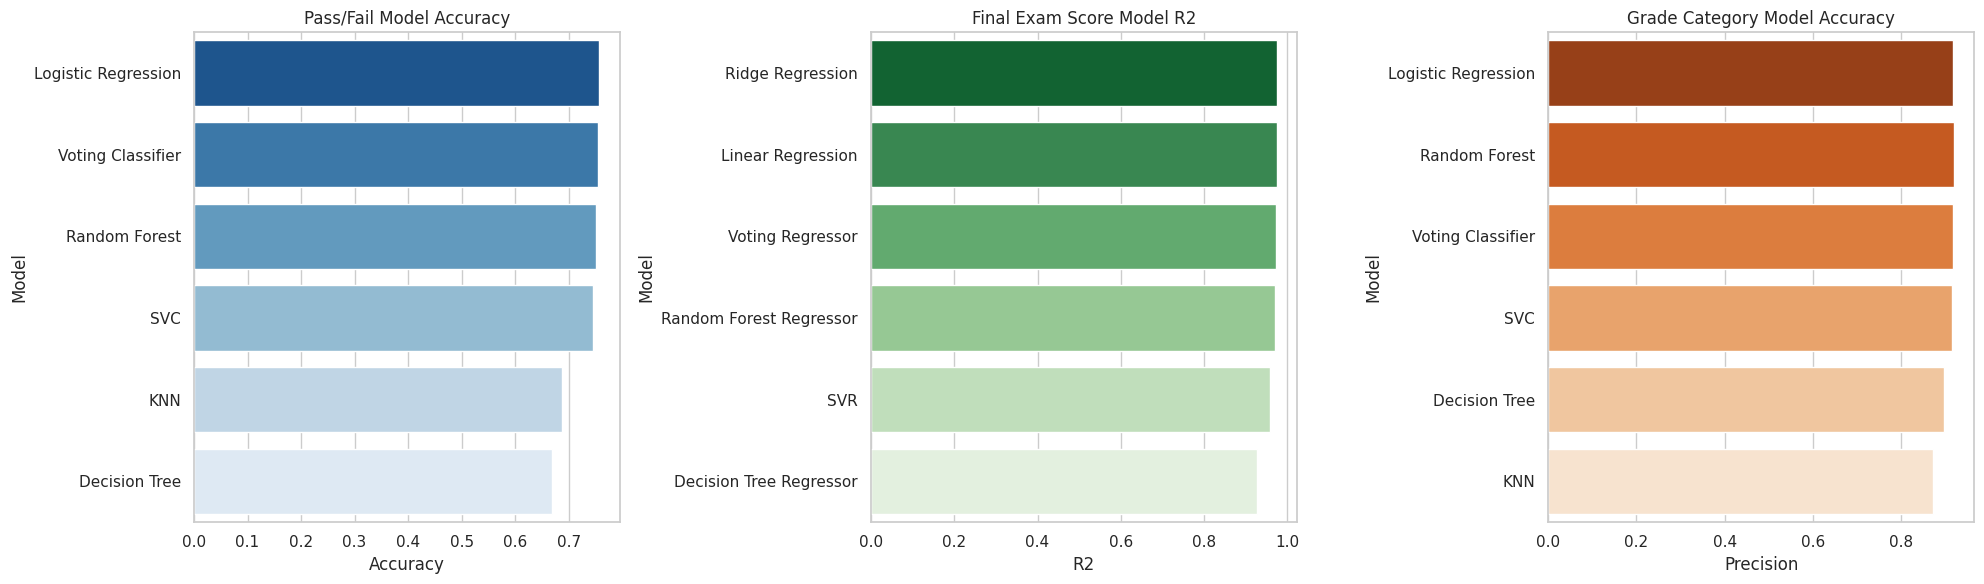

In [11]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=step1_final_df, x="Accuracy", y="Model", palette="Blues_r", ax=axes[0])
axes[0].set_title("Pass/Fail Model | Accuracy")

sns.barplot(data=step2_final_df, x="R2", y="Model", palette="Greens_r", ax=axes[1])
axes[1].set_title("Final Exam Score Model | R2")

sns.barplot(data=step3_final_df, x="Precision", y="Model", palette="Oranges_r", ax=axes[2])
axes[2].set_title("Grade Category Model | Precision")

plt.tight_layout()
plt.show()

In [22]:
print("\n" + "="*50)
print("!!!FINAL TABLES!!!")
print("="*50)

print("\nPASS/FAIL PREDICTION\n:")
print(step1_final_df)

print("\nFINAL EXAM SCORE PREDICTION\n")
print(step2_final_df)

print("\nGRADE CATEGORY PREDICTION\n")
print(step3_final_df)


!!!FINAL TABLES!!!

PASS/FAIL PREDICTION
:
                 Model  Accuracy  Precision    Recall
0  Logistic Regression    0.7575   0.755509  0.740741
1    Voting Classifier    0.7540   0.752632  0.735597
2        Random Forest    0.7505   0.752401  0.725309
3                  SVC    0.7460   0.741164  0.733539
4                  KNN    0.6875   0.675076  0.688272
5        Decision Tree    0.6680   0.663830  0.641975

FINAL EXAM SCORE PREDICTION

                     Model       MAE      RMSE        R2
0         Ridge Regression  1.543377  1.936442  0.974744
1        Linear Regression  1.543391  1.936467  0.974743
2         Voting Regressor  1.560134  1.952712  0.974318
3  Random Forest Regressor  1.678681  2.099298  0.970317
4                      SVR  1.881552  2.505531  0.957718
5  Decision Tree Regressor  2.566250  3.252125  0.928766

GRADE CATEGORY PREDICTION

                 Model  Accuracy  Precision  Recall
0  Logistic Regression    0.9205   0.918477  0.9205
1        Random F